### Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [2]:
df = pd.read_csv(r'D:\Learning\DataScience\Python\Netflix-Analytics-Dashboard\data\netflix_titles.csv')

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


### Dataset Overview

Before diving into the analysis, let's take a quick look at the dataset to understand its size, features, and overall structure.

In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 8807
Number of columns: 12


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
print("Statiscal Summary of column:")
df.describe(include='all')

Statiscal Summary of column:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [8]:
print("Unique Values in each column:")
df.nunique()

Unique Values in each column:


show_id         8807
type               2
title           8807
director        4528
cast            7692
country          748
date_added      1767
release_year      74
rating            17
duration         220
listed_in        514
description     8775
dtype: int64

In [9]:
print("Total duplicate entries: ",df.duplicated().sum())

Total duplicate entries:  0


In [10]:
print("Missing values in each column:")
df.isnull().sum()

Missing values in each column:


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [11]:
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": df.isnull().mean()*100
})

missing = missing[missing["Missing_Count"]>0].sort_values(
    by="Missing_Count",
    ascending=False
)

missing

,Missing_Count,Missing_Percentage
director,2634,29.908028
country,831,9.435676
cast,825,9.367549
date_added,10,0.113546
rating,4,0.045418
duration,3,0.034064


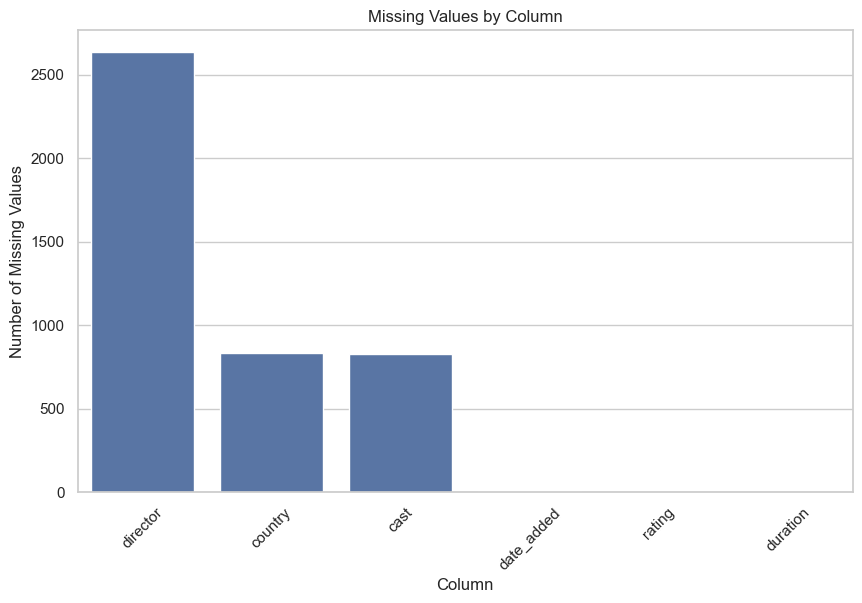

In [12]:
missing_plot = missing[missing["Missing_Count"]>0]

plt.figure(figsize=(10,6))

sns.barplot(
    x=missing_plot.index,
    y=missing_plot["Missing_Count"]
)

plt.title("Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)

plt.show()

In [13]:
print("Minimum release year:", df['release_year'].min())
print("Maximum release year:", df['release_year'].max())

print("\n Release Year Summary: \n", df['release_year'].describe())

Minimum release year: 1925
Maximum release year: 2021

 Release Year Summary: 
 count    8807.000000
mean     2014.180198
std         8.819312
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64


### Data Cleaning and Transformation

In [14]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [15]:
# Changing Datatypes

df['date_added'] = df['date_added'].str.strip()

df['date_added'] = pd.to_datetime(
    df['date_added'],
    errors='coerce'
)



In [16]:
print("Data Type of 'date_added':",df['date_added'].dtype)
print("Sample values:")
df[["date_added"]].head()

Data Type of 'date_added': datetime64[ns]
Sample values:


,date_added
0,2021-09-25
1,2021-09-24
2,2021-09-24
3,2021-09-24
4,2021-09-24


In [17]:
print("Remaining missing values in 'date_added':",df['date_added'].isnull().sum())

Remaining missing values in 'date_added': 10


In [18]:
# Replace Null value with Unknown value
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')
df['duration'] = df['duration'].fillna('Unknown')

In [19]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64

### Feature Engineering

In [20]:
# Extract year, month number, and month name from the 'date_added' column
df['added_year'] = df['date_added'].dt.year
df['added_month'] = df['date_added'].dt.month
df['added_month_name'] = df['date_added'].dt.month_name()

# Display the newly created date-related features
df[
    [
        "date_added",
        "added_year",
        "added_month",
        "added_month_name"
    ]
].head()

,date_added,added_year,added_month,added_month_name
0,2021-09-25,2021.0,9.0,September
1,2021-09-24,2021.0,9.0,September
2,2021-09-24,2021.0,9.0,September
3,2021-09-24,2021.0,9.0,September
4,2021-09-24,2021.0,9.0,September


In [21]:
# Extract numerical value from the 'duration' column
df['duration_value'] = pd.to_numeric(
    df['duration'].str.extract(r"(\d+)")[0],
    errors="coerce"
)

df[['duration_value']].head()

,duration_value
0,90.0
1,2.0
2,1.0
3,1.0
4,2.0


In [22]:
# Separate movie duration (minutes) and TV duration (seasons)
df["duration_minutes"] = np.where(
    df["type"] == "Movie", df["duration_value"], np.nan
)

df["seasons"] = np.where(
    df["type"] == "TV Show", df["duration_value"], np.nan
)

df[
    [
        "duration_minutes",
        "seasons",
    ]
].head()

,duration_minutes,seasons
0,90.0,NaN
1,NaN,2.0
2,NaN,1.0
3,NaN,1.0
4,NaN,2.0


In [23]:
# Calculate content age when added to Netflix
df["content_age"] = df["added_year"] - df["release_year"]

In [24]:
# Audience Maturity Buckets
rating_map = {
    "G": "Kids & Family",
    "PG": "Kids & Family",
    "TV-Y": "Kids & Family",
    "TV-Y7": "Kids & Family",
    "TV-Y7-FV": "Kids & Family",
    "TV-G": "Kids & Family",
    "PG-13": "Teens / YA",
    "TV-14": "Teens / YA",
    "R": "Mature / Adult",
    "NC-17": "Mature / Adult",
    "TV-MA": "Mature / Adult",
    "UR": "Unrated",
    "NR": "Unrated",
    "Unknown": "Unrated",
}
df["maturity_bucket"] = df["rating"].map(rating_map).fillna("Unrated")

display(
    df[['rating', 'maturity_bucket']].head()
)

,rating,maturity_bucket
0,PG-13,Teens / YA
1,TV-MA,Mature / Adult
2,TV-MA,Mature / Adult
3,TV-MA,Mature / Adult
4,TV-MA,Mature / Adult


### Final Dataset Preparation and Export

In [25]:
df_clean = df.copy()

df_clean.shape

(8807, 20)

In [26]:
df_clean.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,added_year,added_month,added_month_name,duration_value,duration_minutes,seasons,content_age,maturity_bucket
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0,September,90.0,90.0,NaN,1.0,Teens / YA
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0,September,2.0,NaN,2.0,0.0,Mature / Adult
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0,September,1.0,NaN,1.0,0.0,Mature / Adult
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0,September,1.0,NaN,1.0,0.0,Mature / Adult
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0,September,2.0,NaN,2.0,0.0,Mature / Adult


In [27]:
df_clean.to_csv(
    "netflix_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
